In [30]:
%pip install pandas numpy matplotlib plotly openpyxl streamlit


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [32]:
import pandas as pd
import numpy as np

print("Loading and rebuilding Austria dataset from source...")

# Step 1: Load raw data
print("\n1. Loading raw data...")
df = pd.read_pickle("../data/raw/AT.pkl")
print(f"   Loaded: {df.shape}")

# Step 2: Clean and rename columns
print("\n2. Cleaning and renaming columns...")
columns_to_drop = ['Unnamed: 0']
df = df.drop(columns=columns_to_drop, errors='ignore')

column_rename_map = {
    'Company name Latin alphabet': 'company_name',
    'Country ISO code': 'country_code',
    'City\nLatin Alphabet': 'city',
    'NACE Rev. 2, core code (4 digits)': 'nace_code',
    'BvD ID number': 'bvd_id',
    'NACE Rev. 2 main section': 'nace_section',
    'Region in country': 'region_raw',
    'Status': 'status',
    'Date of incorporation': 'incorporation_date',
    'Number of employees\n2024': 'emp_2024_raw',
    'Number of employees\n2023': 'emp_2023_raw',
    'Number of employees\n2022': 'emp_2022_raw',
    'Number of employees\n2021': 'emp_2021_raw',
    'Number of employees\n2020': 'emp_2020_raw',
    'Number of employees\n2019': 'emp_2019_raw',
    'Number of employees\n2018': 'emp_2018_raw',
    'Number of employees\n2017': 'emp_2017_raw',
    'Founded Year': 'founded_year',
    'Region in country clean': 'region'
}
df = df.rename(columns=column_rename_map)
print(f"   Renamed cols: {len(column_rename_map)}")

# Step 3: Create numeric employee columns
print("\n3. Creating numeric employee columns...")
years = [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
for year in years:
    raw_col = f'emp_{year}_raw'
    num_col = f'emp_{year}_num'
    df[num_col] = pd.to_numeric(df[raw_col], errors='coerce')

# Step 4: Calculate growth variables
print("\n4. Calculating growth variables...")
for year in [2022, 2023, 2024]:
    prev_year = year - 1
    col_name = f'growth_{year}'
    df[col_name] = ((df[f'emp_{year}_num'] - df[f'emp_{prev_year}_num']) / df[f'emp_{prev_year}_num'] * 100)

# Step 5: Calculate AAGR (Compound Annual Growth Rate)
print("\n5. Calculating AAGR 2024...")
# AAGR = (Ending Value / Beginning Value) ^ (1/n years) - 1
# Using 2021-2024 (3 years)
df['aagr_2024'] = ((df['emp_2024_num'] / df['emp_2021_num']) ** (1/3) - 1) * 100

# Step 6: Create classification (following 03_classification.ipynb)
print("\n6. Creating ConsistentHighGrowthFirm classification...")
df['ConsistentHighGrowthFirm_2024'] = pd.Series(['n.a.'] * len(df), dtype=object)

required_growth_vars = ['growth_2022', 'growth_2023', 'growth_2024', 'aagr_2024']
missing_mask = (
    (df['growth_2022'].isna()) |
    (df['growth_2023'].isna()) |
    (df['growth_2024'].isna()) |
    (df['aagr_2024'].isna())
)

# Size threshold: at least 10 employees in 2021
size_mask = df['emp_2021_num'] < 10

# Rule 3 & Rule 4: Mark as "n.a." if missing variables or too small
df.loc[missing_mask | size_mask, 'ConsistentHighGrowthFirm_2024'] = 'n.a.'

# High-growth classification for remaining firms
classifiable = ~(missing_mask | size_mask)
yearly_growth_gt_20 = (
    ((df['growth_2022'] > 20) & classifiable).astype(int) +
    ((df['growth_2023'] > 20) & classifiable).astype(int) +
    ((df['growth_2024'] > 20) & classifiable).astype(int)
)

high_growth = (
    (yearly_growth_gt_20 >= 2) & 
    (df['aagr_2024'] > 20) & 
    (classifiable)
)

df.loc[high_growth, 'ConsistentHighGrowthFirm_2024'] = 1
df.loc[classifiable & ~high_growth, 'ConsistentHighGrowthFirm_2024'] = 0

print(f"   Classification complete: 1={((df['ConsistentHighGrowthFirm_2024'] == 1).sum())}, "
      f"0={((df['ConsistentHighGrowthFirm_2024'] == 0).sum())}, "
      f"n.a.={((df['ConsistentHighGrowthFirm_2024'] == 'n.a.').sum())}")

print(f"\n✓ Successfully rebuilt data with shape: {df.shape}")
print(f"  Features: {df.columns.tolist()}")


Loading and rebuilding Austria dataset from source...

1. Loading raw data...
   Loaded: (46085, 20)

2. Cleaning and renaming columns...
   Renamed cols: 19

3. Creating numeric employee columns...

4. Calculating growth variables...

5. Calculating AAGR 2024...

6. Creating ConsistentHighGrowthFirm classification...
   Classification complete: 1=150, 0=18479, n.a.=27456

✓ Successfully rebuilt data with shape: (46085, 32)
  Features: ['company_name', 'country_code', 'city', 'nace_code', 'bvd_id', 'nace_section', 'region_raw', 'status', 'incorporation_date', 'emp_2024_raw', 'emp_2023_raw', 'emp_2022_raw', 'emp_2021_raw', 'emp_2020_raw', 'emp_2019_raw', 'emp_2018_raw', 'emp_2017_raw', 'founded_year', 'region', 'emp_2017_num', 'emp_2018_num', 'emp_2019_num', 'emp_2020_num', 'emp_2021_num', 'emp_2022_num', 'emp_2023_num', 'emp_2024_num', 'growth_2022', 'growth_2023', 'growth_2024', 'aagr_2024', 'ConsistentHighGrowthFirm_2024']


In [33]:
df["ConsistentHighGrowthFirm_2024"].value_counts(dropna=False)

ConsistentHighGrowthFirm_2024
n.a.    27456
0       18479
1         150
Name: count, dtype: int64

In [34]:
total = len(df)
summary_counts = df["ConsistentHighGrowthFirm_2024"].value_counts(dropna=False)

print("Classification summary:")
print(summary_counts)
print("\nShares:")
print((summary_counts / total * 100).round(2))

Classification summary:
ConsistentHighGrowthFirm_2024
n.a.    27456
0       18479
1         150
Name: count, dtype: int64

Shares:
ConsistentHighGrowthFirm_2024
n.a.    59.58
0       40.10
1        0.33
Name: count, dtype: float64


In [35]:
analysis = df.copy()

analysis["classification_available"] = analysis["ConsistentHighGrowthFirm_2024"].apply(
    lambda x: 0 if x == "n.a." else 1
)

analysis["chg_2024"] = analysis["ConsistentHighGrowthFirm_2024"].apply(
    lambda x: np.nan if x == "n.a." else int(x)
)

In [36]:
def size_band(emp):
    if pd.isna(emp):
        return "n.a."
    elif emp < 10:
        return "<10"
    elif emp <= 19:
        return "10-19"
    elif emp <= 49:
        return "20-49"
    elif emp <= 249:
        return "50-249"
    else:
        return "250+"

analysis["size_band_2021"] = analysis["emp_2021_num"].apply(size_band)

In [37]:
total_firms = len(analysis)
classifiable_firms = analysis["classification_available"].sum()
not_classifiable_firms = total_firms - classifiable_firms
high_growth_firms = analysis["chg_2024"].sum(skipna=True)

overall_summary = pd.DataFrame({
    "metric": [
        "Total firms",
        "Classifiable firms",
        "Not classifiable firms",
        "Share classifiable",
        "Consistent high-growth firms",
        "Share high-growth among classifiable firms"
    ],
    "value": [
        total_firms,
        classifiable_firms,
        not_classifiable_firms,
        classifiable_firms / total_firms if total_firms > 0 else np.nan,
        high_growth_firms,
        high_growth_firms / classifiable_firms if classifiable_firms > 0 else np.nan
    ]
})

overall_summary

,metric,value
0,Total firms,46085.000000
1,Classifiable firms,18629.000000
2,Not classifiable firms,27456.000000
3,Share classifiable,0.404231
4,Consistent high-growth firms,150.000000
5,Share high-growth among classifiable firms,0.008052


In [38]:
industry_summary = (
    analysis
    .groupby("nace_section", dropna=False)
    .agg(
        total_firms=("bvd_id", "count"),
        classifiable_firms=("classification_available", "sum"),
        high_growth_firms=("chg_2024", "sum")
    )
    .reset_index()
)

industry_summary["share_classifiable"] = (
    industry_summary["classifiable_firms"] / industry_summary["total_firms"]
)

industry_summary["share_high_growth_among_classifiable"] = (
    industry_summary["high_growth_firms"] / industry_summary["classifiable_firms"]
)

industry_summary = industry_summary.sort_values(
    "share_high_growth_among_classifiable", ascending=False
)

industry_summary.head(15)

,nace_section,total_firms,classifiable_firms,high_growth_firms,share_classifiable,share_high_growth_among_classifiable
3,"D - Electricity, gas, steam and air conditioni...",153,68,3.0,0.444444,0.044118
9,J - Information and communication,1703,567,9.0,0.332942,0.015873
13,N - Administrative and support service activities,2673,813,12.0,0.304153,0.014760
12,"M - Professional, scientific and technical act...",4035,905,13.0,0.224287,0.014365
17,"R - Arts, entertainment and recreation",704,161,2.0,0.228693,0.012422
8,I - Accommodation and food service activities,4989,1171,13.0,0.234716,0.011102
15,P - Education,329,91,1.0,0.276596,0.010989
10,K - Financial and insurance activities,1455,533,5.0,0.366323,0.009381
7,H - Transportation and storage,2658,1331,11.0,0.500752,0.008264
4,"E - Water supply; sewerage, waste management a...",237,131,1.0,0.552743,0.007634


In [39]:
region_summary = (
    analysis
    .groupby("region", dropna=False)
    .agg(
        total_firms=("bvd_id", "count"),
        classifiable_firms=("classification_available", "sum"),
        high_growth_firms=("chg_2024", "sum")
    )
    .reset_index()
)

region_summary["share_classifiable"] = (
    region_summary["classifiable_firms"] / region_summary["total_firms"]
)

region_summary["share_high_growth_among_classifiable"] = (
    region_summary["high_growth_firms"] / region_summary["classifiable_firms"]
)

region_summary = region_summary.sort_values(
    "share_high_growth_among_classifiable", ascending=False
)

region_summary

,region,total_firms,classifiable_firms,high_growth_firms,share_classifiable,share_high_growth_among_classifiable
1,Burgenland,1248,505,6.0,0.404647,0.011881
9,Wien,10066,3108,35.0,0.308762,0.011261
4,Oberosterreich,7884,3896,37.0,0.494165,0.009497
6,Steiermark,5966,2455,19.0,0.411498,0.007739
5,Salzburg,3935,1711,12.0,0.434816,0.007013
7,Tirol,4630,1794,12.0,0.387473,0.006689
3,Niederosterreich,7118,3047,20.0,0.428070,0.006564
8,Vorarlberg,2290,916,5.0,0.400000,0.005459
2,Karnten,2691,1108,4.0,0.411743,0.003610
0,,257,89,0.0,0.346304,0.000000


In [40]:
size_summary = (
    analysis
    .groupby("size_band_2021", dropna=False)
    .agg(
        total_firms=("bvd_id", "count"),
        classifiable_firms=("classification_available", "sum"),
        high_growth_firms=("chg_2024", "sum")
    )
    .reset_index()
)

size_summary["share_classifiable"] = (
    size_summary["classifiable_firms"] / size_summary["total_firms"]
)

size_summary["share_high_growth_among_classifiable"] = (
    size_summary["high_growth_firms"] / size_summary["classifiable_firms"]
)

size_summary

,size_band_2021,total_firms,classifiable_firms,high_growth_firms,share_classifiable,share_high_growth_among_classifiable
0,10-19,13974,7586,64.0,0.542865,0.008437
1,20-49,10781,6389,54.0,0.592617,0.008452
2,250+,1426,1045,5.0,0.732819,0.004785
3,50-249,5532,3609,27.0,0.652386,0.007481
4,<10,4446,0,0.0,0.000000,NaN
5,n.a.,9926,0,0.0,0.000000,NaN


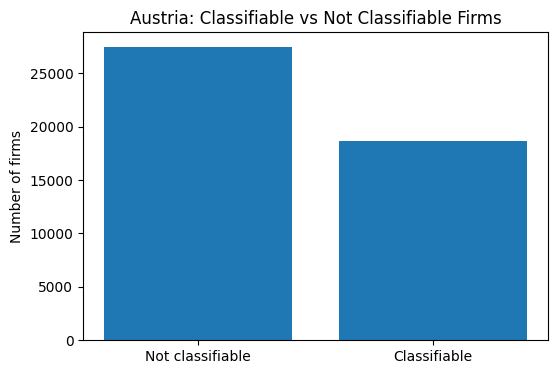

In [41]:
availability = analysis["classification_available"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(["Not classifiable", "Classifiable"], [availability.get(0, 0), availability.get(1, 0)])
plt.title("Austria: Classifiable vs Not Classifiable Firms")
plt.ylabel("Number of firms")
plt.show()

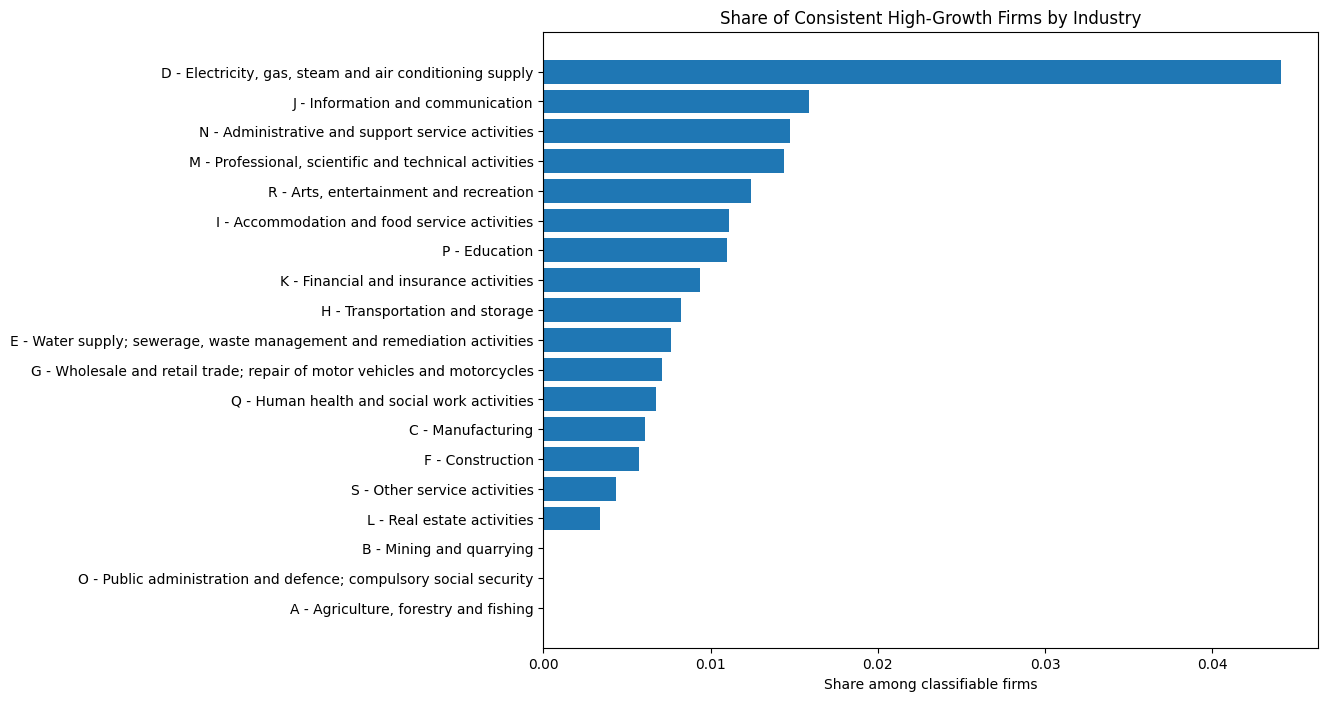

In [42]:
plot_industry = industry_summary.dropna(subset=["share_high_growth_among_classifiable"]).copy()
plot_industry = plot_industry.sort_values("share_high_growth_among_classifiable", ascending=True)

plt.figure(figsize=(10,8))
plt.barh(plot_industry["nace_section"], plot_industry["share_high_growth_among_classifiable"])
plt.title("Share of Consistent High-Growth Firms by Industry")
plt.xlabel("Share among classifiable firms")
plt.show()

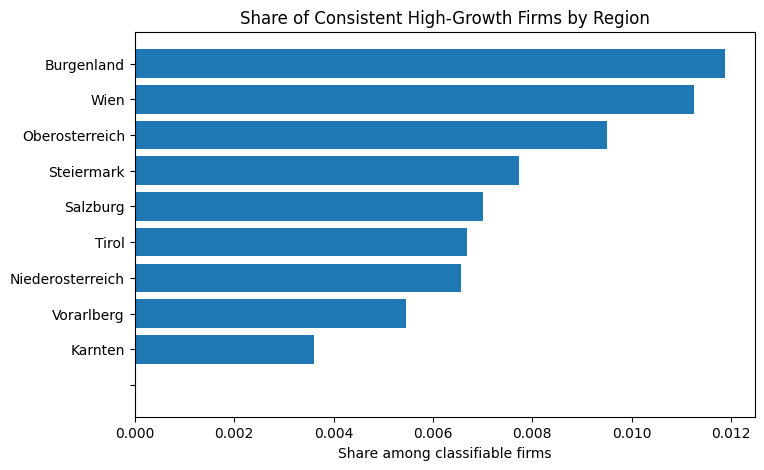

In [43]:
plot_region = region_summary.dropna(subset=["share_high_growth_among_classifiable"]).copy()
plot_region = plot_region.sort_values("share_high_growth_among_classifiable", ascending=True)

plt.figure(figsize=(8,5))
plt.barh(plot_region["region"], plot_region["share_high_growth_among_classifiable"])
plt.title("Share of Consistent High-Growth Firms by Region")
plt.xlabel("Share among classifiable firms")
plt.show()

In [44]:
analysis = df.copy()

analysis["classification_available"] = analysis["ConsistentHighGrowthFirm_2024"].apply(
    lambda x: 0 if x == "n.a." else 1
)

analysis["chg_2024"] = analysis["ConsistentHighGrowthFirm_2024"].apply(
    lambda x: np.nan if x == "n.a." else int(x)
)

def size_band(emp):
    if pd.isna(emp):
        return "n.a."
    elif emp < 10:
        return "<10"
    elif emp <= 19:
        return "10-19"
    elif emp <= 49:
        return "20-49"
    elif emp <= 249:
        return "50-249"
    else:
        return "250+"

analysis["size_band_2021"] = analysis["emp_2021_num"].apply(size_band)